<div align="center">
  <h1>📈 <b>BIST Portfolio Visualization & Aggregation</b></h1>
  <h3>Weeks 5 & 6 — Python for Data Analysis (Ch. 9–10)</h3>
</div>

<hr>

**Role:** <span style="color:#0077b6">Quantitative Analyst</span>  

**Objective:** <br>
You are refining the risk management and signal generation modules for an automated trading system. To do this, you need to analyze the historical price action and trading volume of a BIST mini-portfolio. You will group the data to calculate multi-column summaries and create a dashboard of visualizations to identify volatility and trends.

## 💾 Dataset Preparation <span style="color:#888">(Official Secondary Source)</span>
You will use the <b><code>yfinance</code></b> library to download real-world daily stock data for four major Borsa Istanbul equities.

---

### ⚙️ Setup Instructions
<span style="color:#888">Run the following code in your first cell to gather and shape the data:</span>

In [34]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
#### Download 1 year of daily data for a BIST mini-portfolio

In [35]:
tickers = ["THYAO.IS", "GARAN.IS", "KCHOL.IS", "TUPRS.IS"]
df = yf.download(tickers, period="1y", group_by="ticker")

[*********************100%***********************]  4 of 4 completed


---
#### Reshape the data into a tidy format for easier groupby and plotting

In [36]:
df.head()

Ticker        THYAO.IS                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2025-02-19  317.243150  318.464255  309.672297  310.893402  32683908   
2025-02-20  311.381824  317.731571  307.718509  308.451172  33188614   
2025-02-21  308.939630  310.160735  298.438125  302.101440  39089686   
2025-02-24  305.276325  306.985873  301.368788  302.345673  25538534   
2025-02-25  302.589865  304.299412  297.217002  297.705444  23823247   

Ticker        TUPRS.IS                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2025-02-19  118.528523  118.892116  114.165514  114.256409  37594544   
2025-02-20  114.438200  116.710596  114.438200  116.074326  21997856   
2025-02-21  116.074329  116.892402  112.529386  114.165512  25566791   
2025-02-24  115.256262  115.710743  113.801919  114.529091  15180646   
2025-02-25  114.619988  114.892679  111.984000  112.256691  19673967   

Ticker        GARAN.IS                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2025-02-19  125.750417  126.329029  123.628863  123.725304  21982830   
2025-02-20  124.303900  127.679103  124.303900  126.136162  34256634   
2025-02-21  126.329028  126.618334  121.603742  123.435997  25644853   
2025-02-24  124.689650  124.978956  120.350104  120.832275  21661219   
2025-02-25  120.735831  122.953825  119.867928  121.507309  33619334   

Ticker        KCHOL.IS                                                
Price             Open        High         Low       Close    Volume  
Date                                                                  
2025-02-19  150.955030  153.152479  143.311737  143.311737  70931074  
2025-02-20  144.553769  144.935927  142.451866  143.120651  30735896  
2025-02-21  143.216180  146.942293  140.541039  143.884979  43701907  
2025-02-24  145.222561  145.700267  143.311738  143.789444  18228493  
2025-02-25  144.267152  145.700270  143.407288  143.407288  20567844

In [37]:
df.stack().head()

Ticker                 THYAO.IS      TUPRS.IS      GARAN.IS      KCHOL.IS
Date       Price                                                         
2025-02-19 Open    3.172431e+02  1.185285e+02  1.257504e+02  1.509550e+02
           High    3.184643e+02  1.188921e+02  1.263290e+02  1.531525e+02
           Low     3.096723e+02  1.141655e+02  1.236289e+02  1.433117e+02
           Close   3.108934e+02  1.142564e+02  1.237253e+02  1.433117e+02
           Volume  3.268391e+07  3.759454e+07  2.198283e+07  7.093107e+07

In [38]:
df.stack(level=0)

Price                      Open        High         Low       Close    Volume
Date       Ticker                                                            
2025-02-19 THYAO.IS  317.243150  318.464255  309.672297  310.893402  32683908
           TUPRS.IS  118.528523  118.892116  114.165514  114.256409  37594544
           GARAN.IS  125.750417  126.329029  123.628863  123.725304  21982830
           KCHOL.IS  150.955030  153.152479  143.311737  143.311737  70931074
2025-02-20 THYAO.IS  311.381824  317.731571  307.718509  308.451172  33188614
...                         ...         ...         ...         ...       ...
2026-02-18 KCHOL.IS  221.000000  227.100006  217.399994  218.100006  53337534
2026-02-19 THYAO.IS  330.500000  331.000000  318.500000  319.500000  42955086
           TUPRS.IS  223.600006  229.800003  223.300003  225.100006  33276878
           GARAN.IS  161.899994  162.199997  155.199997  155.899994  16795366
           KCHOL.IS  219.199997  220.899994  213.899994  214.000000  20835338

[1008 rows x 5 columns]

In [39]:
df_tidy = df.stack(level=0).reset_index()
df_tidy.head()

Price,Date,Ticker,Open,High,Low,Close,Volume
0,2025-02-19,THYAO.IS,317.243150,318.464255,309.672297,310.893402,32683908
1,2025-02-19,TUPRS.IS,118.528523,118.892116,114.165514,114.256409,37594544
2,2025-02-19,GARAN.IS,125.750417,126.329029,123.628863,123.725304,21982830
3,2025-02-19,KCHOL.IS,150.955030,153.152479,143.311737,143.311737,70931074
4,2025-02-20,THYAO.IS,311.381824,317.731571,307.718509,308.451172,33188614


In [40]:
df_tidy['Daily_Return'] = df_tidy.groupby('Ticker')['Close'].pct_change() * 100

In [41]:
df_tidy.isna().any()

Price
Date            False
Ticker          False
Open            False
High            False
Low             False
Close           False
Volume          False
Daily_Return     True
dtype: bool

In [42]:
df_tidy[df_tidy['Daily_Return'].isna()]

Price,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return
0,2025-02-19,THYAO.IS,317.243150,318.464255,309.672297,310.893402,32683908,NaN
1,2025-02-19,TUPRS.IS,118.528523,118.892116,114.165514,114.256409,37594544,NaN
2,2025-02-19,GARAN.IS,125.750417,126.329029,123.628863,123.725304,21982830,NaN
3,2025-02-19,KCHOL.IS,150.955030,153.152479,143.311737,143.311737,70931074,NaN


In [47]:
df_tidy['Date'].sort_values(ascending=True)

0      2025-02-19
1      2025-02-19
2      2025-02-19
3      2025-02-19
4      2025-02-20
          ...    
1001   2026-02-18
1005   2026-02-19
1006   2026-02-19
1004   2026-02-19
1007   2026-02-19
Name: Date, Length: 1008, dtype: datetime64[s]

In [48]:
df_tidy.dropna(inplace=True)

## 🧠 <span style="color:#0077b6">Part 1: Data Aggregation</span> <span style="color:#888">(Ch. 10)</span>

> <span style="color:#888">Professional Comment:</span>
> This section focuses on statistical aggregation for risk and performance analysis.

**Goal:** Group the data by stock ticker to calculate statistical summaries.

### 📝 Task 1.1: Multi-Column Summaries with <code>groupby().agg()</code>
The trading desk needs to know the average closing price, maximum daily return, and total trading volume for each asset over the last year.

1. **Group:** Use <code>.groupby("Ticker")</code> on your <code>df_tidy</code> DataFrame.
2. **Compute:** Chain the <code>.agg()</code> method to compute:
   * The <b>mean</b> of the <code>Close</code> column.
   * The <b>max</b> of the <code>Daily_Return</code> column.
   * The <b>sum</b> of the <code>Volume</code> column.
3. **Output:** Store this summary DataFrame in a variable named <code>portfolio_summary</code> and display it.

---
<span style="color:#888">⬇️ Your Solution Below:</span>

In [95]:
portfolio_summary = df_tidy.groupby('Ticker').agg({
    'Close': 'mean',
    'Daily_Return': 'max',
    'Volume': 'sum'
})

portfolio_summary

Price,Close,Daily_Return,Volume
Ticker,,,
GARAN.IS,132.623637,9.934851,7844334139
KCHOL.IS,168.108382,8.048044,7853743697
THYAO.IS,296.641811,8.498030,9121472093
TUPRS.IS,164.692266,9.013610,5155504699


## 📊 <span style="color:#0077b6">Part 2: Data Visualization</span> <span style="color:#888">(Ch. 9)</span>

> <span style="color:#888">Professional Comment:</span>
> Visualization is essential for identifying trends, volatility, and portfolio behavior.

**Goal:** Produce 4 distinct visualizations (Line, Histogram, Scatter, Bar) with proper labels, titles, and legends to assess portfolio behavior.

---

### 📝 Task 2.1: Line Plot (Price Trends)
<span style="color:#888">Visualize the closing price trends to identify macroeconomic movements.</span>

1. Create a figure using <code>plt.figure(figsize=(10, 5))</code>.
2. Use <code>sns.lineplot()</code> to plot <b>Date</b> on the x-axis and <b>Close</b> on the y-axis, setting <code>hue="Ticker"</code> to separate the stocks.
3. Add a proper title ("BIST Mini-Portfolio: 1-Year Closing Prices") and label the y-axis ("Price (TRY)").

---
<span style="color:#888">⬇️ Your Solution Below:</span>

<Axes: xlabel='Date', ylabel='Close'>

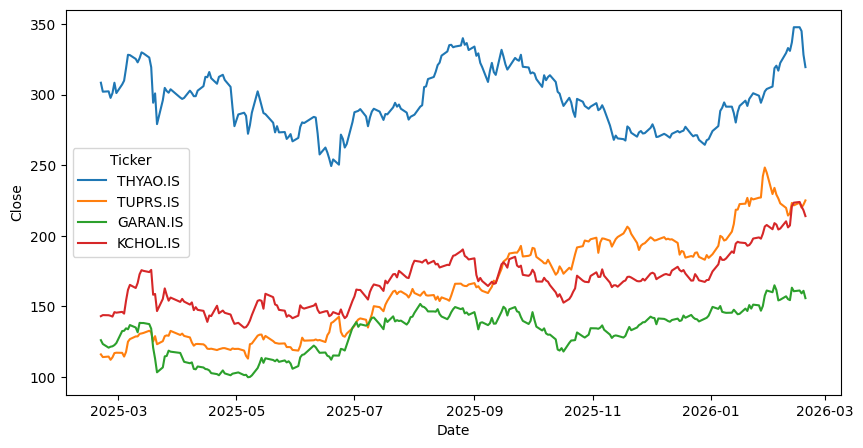

In [52]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Date', y='Close', data=df_tidy, hue="Ticker")

### 📝 Task 2.2: Histogram (Risk & Volatility)
<span style="color:#888">Analyze the distribution of daily returns to understand the risk profile.</span>

1. Filter <code>df_tidy</code> to only include the ticker <b>"THYAO.IS"</b>.
2. Use <code>plt.hist()</code> to plot the <b>Daily_Return</b> of this filtered data. Use <code>bins=30</code> and set <code>alpha=0.7</code>.
3. Add a title ("THYAO.IS Daily Return Distribution"), x-label ("Return (%)"), and y-label ("Frequency").

---
<span style="color:#888">⬇️ Your Solution Below:</span>

Text(0.5, 1.0, 'THYAO.IS Daily Return Distribution')

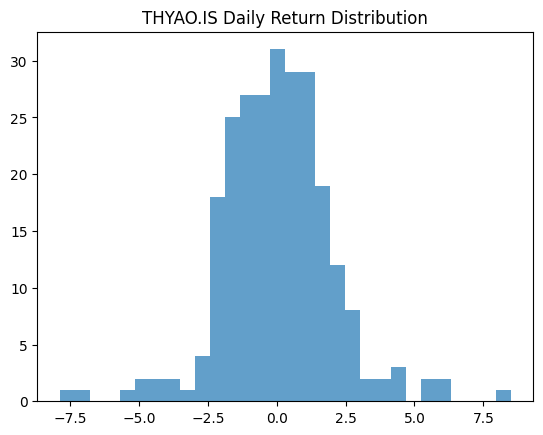

In [59]:
thyao_data = df_tidy[df_tidy['Ticker']=="THYAO.IS"].copy()
plt.hist(thyao_data.Daily_Return, bins=30, alpha=0.7)
plt.title("THYAO.IS Daily Return Distribution")

### 📝 Task 2.3: Scatter Plot (Volume vs. Return)
<span style="color:#888">Investigate if high trading volumes correlate with extreme price movements (useful for volatility breakout signals).</span>

1. Use <code>sns.scatterplot()</code> to plot <b>Volume</b> on the x-axis and <b>Daily_Return</b> on the y-axis.
2. Use <code>hue="Ticker"</code> to color-code the data points by stock.
3. Add a title ("Trading Volume vs. Daily Return") and ensure your axes are clearly labeled.

---
<span style="color:#888">⬇️ Your Solution Below:</span>

Text(0.5, 1.0, 'Trading Volume vs. Daily Return')

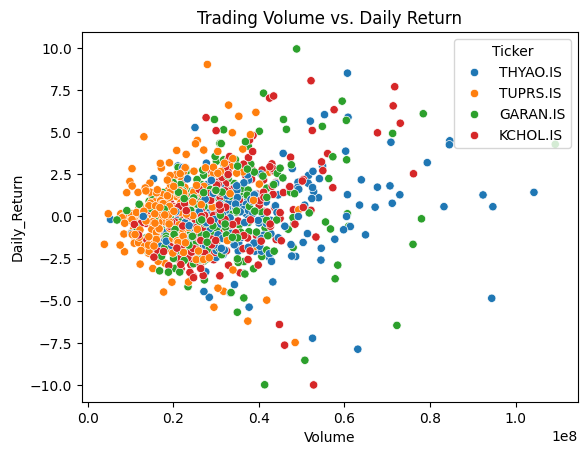

In [93]:
sns.scatterplot(data=df_tidy, x='Volume', y="Daily_Return", hue="Ticker")
plt.title("Trading Volume vs. Daily Return")

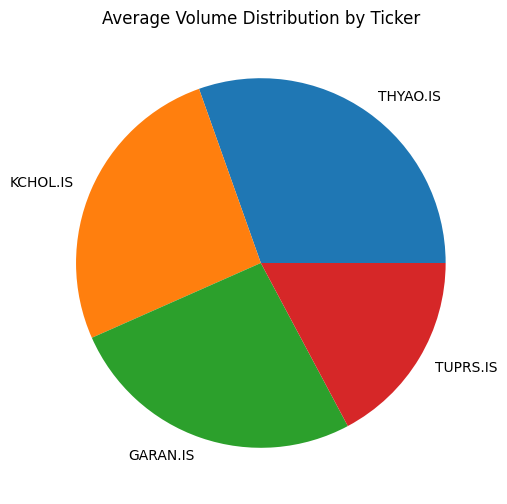

In [91]:
avg_volume = df_tidy.groupby('Ticker')['Volume'].mean().sort_values(ascending=False)

avg_volume.plot.pie(figsize=(6, 6))
plt.ylabel("")  
plt.title("Average Volume Distribution by Ticker")
plt.show()


### 📝 Task 2.4: Bar Chart & Export (Combined Groupby & Plot)
<span style="color:#888">Visualize the aggregated data you calculated in Part 1 and save the final report.</span>

1. Using your <code>portfolio_summary</code> DataFrame from Task 1.1, reset its index so <b>Ticker</b> becomes a standard column.
2. Create a bar chart using <code>sns.barplot()</code>, plotting <b>Ticker</b> on the x-axis and the aggregated average <b>Close</b> price on the y-axis.
3. Give it a title ("Average Closing Price per Asset").

---
<span style="color:#888">⬇️ Your Solution Below:</span>

Text(0.5, 1.0, 'Average Closing Price Per Asset')

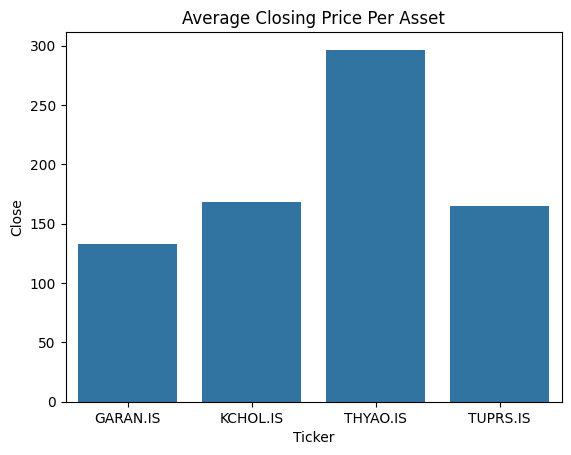

In [97]:
portfolio_summary.reset_index(inplace=True)
sns.barplot(data=portfolio_summary, x='Ticker', y='Close')
plt.title('Average Closing Price Per Asset')